In [1]:
#Libraries
import os
import pandas as pd
print(os.getcwd())

C:\Users\user


In [2]:
dict_format_map_var={
"contract_status":"int64",
"contract_dd_cancels":"int64",  
"dd_cancel_60_day":"int32",  
"ooc_days":"float64",
"technology":"int64",  
"speed":"int32", 
"line_speed":"float64",
"sales_channel":"int64",  
"crm_package_name":"int64",  
"tenure_days":"int32",  
"reason_description_insight":"int64",  
"target":"float64",
"talk_time_seconds":"float64",
"hold_time_seconds":"float64",
"usage_download_mbs":"float64",
"usage_upload_mbs":"float64"
}
df_model=pd.read_csv("df_model.csv",dtype=dict_format_map_var)
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 200714 entries, 0 to 200713
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   contract_status             200714 non-null  int64  
 1   contract_dd_cancels         200714 non-null  int64  
 2   dd_cancel_60_day            200714 non-null  int32  
 3   ooc_days                    199797 non-null  float64
 4   technology                  200714 non-null  int64  
 5   speed                       200714 non-null  int32  
 6   line_speed                  200714 non-null  float64
 7   sales_channel               200714 non-null  int64  
 8   crm_package_name            200714 non-null  int64  
 9   tenure_days                 200714 non-null  int32  
 10  reason_description_insight  200714 non-null  int64  
 11  target                      115491 non-null  float64
 12  talk_time_seconds           127159 non-null  float64
 13  hold_time_seconds        

In [3]:
df=df_model
for i in df_model.columns:
    print(i,":",df[i].nunique())

contract_status : 6
contract_dd_cancels : 2
dd_cancel_60_day : 2
ooc_days : 6044
technology : 4
speed : 9
line_speed : 69878
sales_channel : 13
crm_package_name : 63
tenure_days : 7192
reason_description_insight : 12
target : 1
talk_time_seconds : 15666
hold_time_seconds : 6894
usage_download_mbs : 180787
usage_upload_mbs : 157138


In [4]:
discrete_vars=["contract_status","contract_dd_cancels","dd_cancel_60_day","technology","speed","sales_channel","crm_package_name","reason_description_insight"]
continous_vars=["talk_time_seconds","hold_time_seconds","usage_download_mbs","usage_upload_mbs","line_speed"]

In [5]:
for i in continous_vars:
    if i not in ("target"):
        print(f"Column: {i}",df[[i,"target"]].groupby(by=["target"]).mean())

Column: talk_time_seconds         talk_time_seconds
target                   
1.0           3000.478346
Column: hold_time_seconds         hold_time_seconds
target                   
1.0            936.677139
Column: usage_download_mbs         usage_download_mbs
target                    
1.0           4.110610e+06
Column: usage_upload_mbs         usage_upload_mbs
target                  
1.0        300839.845926
Column: line_speed         line_speed
target            
1.0      32.187948


In [6]:
for i in discrete_vars:
    if i not in ("target"):
        print(f"Column: {i}",df[[i,"target"]].groupby(by=[i]).sum())

Column: contract_status                   target
contract_status         
0                 4977.0
1                15620.0
2                18299.0
3                21589.0
4                20217.0
5                34789.0
Column: contract_dd_cancels                       target
contract_dd_cancels         
0                    70421.0
1                    45070.0
Column: dd_cancel_60_day                    target
dd_cancel_60_day         
0                 83601.0
1                 31890.0
Column: technology              target
technology         
0           97021.0
1             364.0
2            5709.0
3           12397.0
Column: speed         target
speed         
18     12397.0
35     24122.0
40     12235.0
65     60664.0
150     5362.0
250      347.0
500        0.0
900        0.0
1000     364.0
Column: sales_channel                 target
sales_channel         
0               1013.0
1              14179.0
2               7895.0
3              39693.0
4               6839.0
5 

In [7]:
df_model.head(3)

,contract_status,contract_dd_cancels,dd_cancel_60_day,ooc_days,technology,speed,line_speed,sales_channel,crm_package_name,tenure_days,reason_description_insight,target,talk_time_seconds,hold_time_seconds,usage_download_mbs,usage_upload_mbs
0,4,1,0,12.0,0,65,72.994844,1,29,607,10,1.0,1371.0,228.0,19448684.0,504764.0
1,0,0,0,-662.0,0,35,27.399000,2,25,6015,11,NaN,1571.0,194.0,2689619.0,130894.0
2,5,0,0,676.0,0,35,39.997000,6,25,1740,11,NaN,5743.0,1672.0,6921609.0,153166.0


In [21]:
df_model["target"]=df_model["target"].fillna(0)

In [9]:
df_heatmap=df_model.corr()
df_heatmap.to_csv("df_heatmap.csv",index=True)

<Axes: >

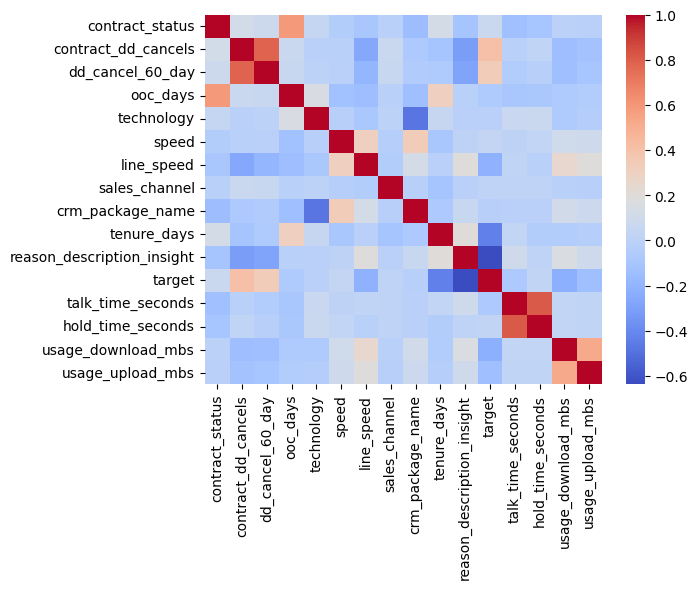

In [10]:
import seaborn as sns
#dir(sns)
#help(sns.heatmap)
sns.heatmap(df_heatmap,fmt='.2g',cmap='coolwarm')

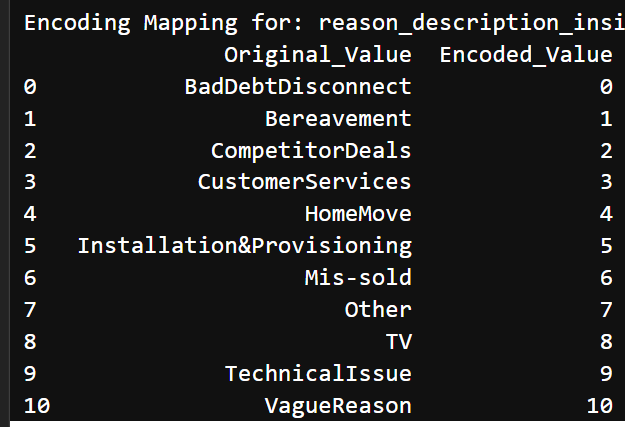

#### Feature Analysis using recursive feature ellimination

In [11]:
for i in df_model.columns:
    print(f"Nulls in {i}: ",df_model[i].isnull().sum())

Nulls in contract_status:  0
Nulls in contract_dd_cancels:  0
Nulls in dd_cancel_60_day:  0
Nulls in ooc_days:  917
Nulls in technology:  0
Nulls in speed:  0
Nulls in line_speed:  0
Nulls in sales_channel:  0
Nulls in crm_package_name:  0
Nulls in tenure_days:  0
Nulls in reason_description_insight:  0
Nulls in target:  0
Nulls in talk_time_seconds:  73555
Nulls in hold_time_seconds:  73555
Nulls in usage_download_mbs:  16041
Nulls in usage_upload_mbs:  16041


In [12]:
from sklearn.feature_selection import RFE
#help(sklearn.feature_selection.RFE)
#help(sklearn.model_selection.train_test_split)
from sklearn.model_selection import train_test_split
df_model_copy=df_model.copy()

from sklearn.impute import SimpleImputer
#elp(sklearn.impute.SimpleImputer)
imp_obj=SimpleImputer(strategy='mean')

df_model_copy=imp_obj.fit_transform(df_model)

In [13]:
# Convert back to dataframe
df_imputed = pd.DataFrame(
    df_model_copy,
    columns=df_model.columns,
    index=df_model.index
)

df_imputed.head()

,contract_status,contract_dd_cancels,dd_cancel_60_day,ooc_days,technology,speed,line_speed,sales_channel,crm_package_name,tenure_days,reason_description_insight,target,talk_time_seconds,hold_time_seconds,usage_download_mbs,usage_upload_mbs
0,4.0,1.0,0.0,12.0,0.0,65.0,72.994844,1.0,29.0,607.0,10.0,1.0,1371.000000,228.000000,19448684.0,504764.0
1,0.0,0.0,0.0,-662.0,0.0,35.0,27.399000,2.0,25.0,6015.0,11.0,0.0,1571.000000,194.000000,2689619.0,130894.0
2,5.0,0.0,0.0,676.0,0.0,35.0,39.997000,6.0,25.0,1740.0,11.0,0.0,5743.000000,1672.000000,6921609.0,153166.0
3,5.0,1.0,1.0,1854.0,3.0,18.0,0.000000,2.0,41.0,5396.0,1.0,1.0,3291.234659,912.196526,58.0,17.0
4,5.0,1.0,0.0,1086.0,0.0,40.0,54.999000,6.0,19.0,2175.0,11.0,0.0,3291.234659,912.196526,6522918.0,258418.0


In [14]:
y=df_imputed.pop("target")
X=df_imputed
print(y.shape)
print(X.shape)

print(type(y))
print(type(X))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

(200714,)
(200714, 15)
<class 'pandas.Series'>
<class 'pandas.DataFrame'>


In [15]:
from sklearn.linear_model import LogisticRegression
estimator = LogisticRegression(max_iter=1000)
selector = RFE(estimator, n_features_to_select=5, step=1)
selector = selector.fit(X_train, y_train)


C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sci

In [16]:
feature_rankings = pd.DataFrame({
    'Feature': X_train.columns,
    'Ranking': selector.ranking_
})

print(feature_rankings.sort_values('Ranking'))

                       Feature  Ranking
0              contract_status        1
1          contract_dd_cancels        1
2             dd_cancel_60_day        1
4                   technology        1
10  reason_description_insight        1
8             crm_package_name        2
7                sales_channel        3
6                   line_speed        4
5                        speed        5
3                     ooc_days        6
9                  tenure_days        7
12           hold_time_seconds        8
11           talk_time_seconds        9
13          usage_download_mbs       10
14            usage_upload_mbs       11


In [17]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [19]:
models = [LogisticRegression(), XGBClassifier(),
          RandomForestClassifier(n_estimators=7,
                                 criterion='entropy',
                                 random_state=7)]

for i in range(len(models)):
    models[i].fit(X_train, y_train)
    print(f'{models[i]} : ')

    train_preds = models[i].predict_proba(X_train)[:, 1]
    print('Training Accuracy : ', ras(y_train, train_preds))

    y_preds = models[i].predict_proba(X_test)[:, 1]
    print('Validation Accuracy : ', ras(y_test, y_preds))
    print()

C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression() : 
Training Accuracy :  0.728193422356038
Validation Accuracy :  0.7269294189709721

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0
Validation Accuracy :  1.0

RandomForestClassifier(criterion='entropy', n_estimators=7, random_state=7) :

In [20]:
X_train.columns

Index(['contract_status', 'contract_dd_cancels', 'dd_cancel_60_day',
       'ooc_days', 'technology', 'speed', 'line_speed', 'sales_channel',
       'crm_package_name', 'tenure_days', 'reason_description_insight',
       'talk_time_seconds', 'hold_time_seconds', 'usage_download_mbs',
       'usage_upload_mbs'],
      dtype='str')

In [23]:
df_model.groupby("contract_status")["target"].mean()

contract_status
0    0.460577
1    0.356369
2    0.752209
3    0.853354
4    0.793166
5    0.490248
Name: target, dtype: float64

In [24]:
df_model.groupby("reason_description_insight")["target"].mean()

reason_description_insight
0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    0.0
Name: target, dtype: float64

In [25]:
df_model.groupby("speed")["target"].mean()

speed
18      0.557169
35      0.507757
40      0.688326
65      0.590077
150     0.568792
250     0.677734
500     0.000000
900     0.000000
1000    0.928571
Name: target, dtype: float64

In [26]:
df_model.groupby("technology")["target"].mean()

technology
0    0.578056
1    0.418391
2    0.585298
3    0.557169
Name: target, dtype: float64